In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

import warnings
warnings.filterwarnings('ignore')

def train_test_split_manual(X, y, test_size=0.2, random_state=None):
    if random_state is not None:
        np.random.seed(random_state)
    
    n_samples = len(X)
    n_test = int(n_samples * test_size)
    
    indices = np.arange(n_samples)
    np.random.shuffle(indices)
    
    test_indices = indices[:n_test]
    train_indices = indices[n_test:]
    
    if isinstance(X, pd.DataFrame):
        X_train = X.iloc[train_indices].reset_index(drop=True)
        X_test = X.iloc[test_indices].reset_index(drop=True)
    else:
        X_train = X[train_indices]
        X_test = X[test_indices]
    
    if isinstance(y, pd.Series):
        y_train = y.iloc[train_indices].reset_index(drop=True)
        y_test = y.iloc[test_indices].reset_index(drop=True)
    else:
        y_train = y[train_indices]
        y_test = y[test_indices]
    
    return X_train, X_test, y_train, y_test

def mean_squared_error_manual(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean((y_true - y_pred) ** 2)

def mean_absolute_error_manual(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.abs(y_true - y_pred))

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [40]:
df = pd.read_csv('RatingsMovies.csv')
print(f"Số lượng phim: {df['movie_id'].nunique()}")
print(f"Số lượng user: {df['user_id'].nunique()}")
print(f"\nPhân bố rating:")
print(df['rating'].value_counts().sort_index())
print(f"\nThống kê rating:")
print(df['rating'].describe())
print("5 dòng đầu tiên")
df.head()

Số lượng phim: 1682
Số lượng user: 943

Phân bố rating:
rating
1     6110
2    11370
3    27145
4    34174
5    21201
Name: count, dtype: int64

Thống kê rating:
count    100000.000000
mean          3.529860
std           1.125674
min           1.000000
25%           3.000000
50%           4.000000
75%           4.000000
max           5.000000
Name: rating, dtype: float64
5 dòng đầu tiên


,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [41]:
print("\nGiá trị trống:")
print(df.isnull().sum())
print(f"\nTrùng lặp: {df.duplicated().sum()}")
print("\nKiểu dữ liệu:")
print(df.dtypes)


Giá trị trống:
user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64

Trùng lặp: 0

Kiểu dữ liệu:
user_id      int64
movie_id     int64
rating       int64
timestamp    int64
dtype: object


In [ ]:
df_processed = df.copy()

df_processed['datetime'] = pd.to_datetime(df_processed['timestamp'], unit='s')
df_processed['year'] = df_processed['datetime'].dt.year
df_processed['month'] = df_processed['datetime'].dt.month
df_processed['day_of_week'] = df_processed['datetime'].dt.dayofweek  
df_processed['hour'] = df_processed['datetime'].dt.hour

user_stats = df_processed.groupby('user_id')['rating'].agg([
    ('user_avg_rating', 'mean'),
    ('user_rating_count', 'count'),
    ('user_rating_std', 'std')
]).reset_index()
user_stats['user_rating_std'] = user_stats['user_rating_std'].fillna(0)

movie_stats = df_processed.groupby('movie_id')['rating'].agg([
    ('movie_avg_rating', 'mean'),
    ('movie_rating_count', 'count'),
    ('movie_rating_std', 'std')
]).reset_index()
movie_stats['movie_rating_std'] = movie_stats['movie_rating_std'].fillna(0)
df_processed = df_processed.merge(user_stats, on='user_id', how='left')
df_processed = df_processed.merge(movie_stats, on='movie_id', how='left')

print("Features sau xử lý")
print(f"Số lượng features: {df_processed.shape[1]}")
print(f"\nDanh sách features:")
for i, col in enumerate(df_processed.columns, 1):
    print(f"{i}. {col}")

print("\nDữ liệu sau xử lý")
df_processed.head(10)

Features sau xử lý
Số lượng features: 15

Danh sách features:
1. user_id
2. movie_id
3. rating
4. timestamp
5. datetime
6. year
7. month
8. day_of_week
9. hour
10. user_avg_rating
11. user_rating_count
12. user_rating_std
13. movie_avg_rating
14. movie_rating_count
15. movie_rating_std

Dữ liệu sau xử lý


,user_id,movie_id,rating,timestamp,datetime,year,month,day_of_week,hour,user_avg_rating,user_rating_count,user_rating_std,movie_avg_rating,movie_rating_count,movie_rating_std
0,196,242,3,881250949,1997-12-04 15:55:49,1997,12,3,15,3.615385,39,1.016065,3.991453,117,0.995643
1,186,302,3,891717742,1998-04-04 19:22:22,1998,4,5,19,3.413043,92,1.223867,4.161616,297,0.854721
2,22,377,1,878887116,1997-11-07 07:18:36,1997,11,4,7,3.351562,128,1.493239,2.153846,13,1.068188
3,244,51,2,880606923,1997-11-27 05:02:03,1997,11,3,5,3.651261,238,1.071406,3.456790,81,1.162426
4,166,346,1,886397596,1998-02-02 05:33:16,1998,2,0,5,3.550000,20,1.431782,3.642857,126,1.084172
5,298,474,4,884182806,1998-01-07 14:20:06,1998,1,2,14,4.031496,127,0.815884,4.252577,194,0.853593
6,115,265,2,881171488,1997-12-03 17:51:28,1997,12,2,17,3.934783,92,1.174868,3.863436,227,0.889383
7,253,465,5,891628467,1998-04-03 18:34:27,1998,4,4,18,3.979381,97,0.957203,3.564706,85,1.062870
8,305,451,3,886324817,1998-02-01 09:20:17,1998,2,6,9,3.409910,222,1.079840,3.347059,170,1.232027
9,6,86,3,883603013,1997-12-31 21:16:53,1997,12,2,21,3.635071,211,1.039461,3.940000,150,0.984647


In [43]:
feature_columns = [
    'user_id', 'movie_id', 
    'year', 'month', 'day_of_week', 'hour',
    'user_avg_rating', 'user_rating_count', 'user_rating_std',
    'movie_avg_rating', 'movie_rating_count', 'movie_rating_std'
]

X = df_processed[feature_columns]
y = df_processed['rating']

print(f"\nShape của X: {X.shape}")
print(f"Shape của y: {y.shape}")
print(f"\nFeatures được sử dụng:")
for i, col in enumerate(feature_columns, 1):
    print(f"   {i}. {col}")

print("Thống kê")
X.describe()


Shape của X: (100000, 12)
Shape của y: (100000,)

Features được sử dụng:
   1. user_id
   2. movie_id
   3. year
   4. month
   5. day_of_week
   6. hour
   7. user_avg_rating
   8. user_rating_count
   9. user_rating_std
   10. movie_avg_rating
   11. movie_rating_count
   12. movie_rating_std
Thống kê


,user_id,movie_id,year,month,day_of_week,hour,user_avg_rating,user_rating_count,user_rating_std,movie_avg_rating,movie_rating_count,movie_rating_std
count,100000.00000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,462.48475,425.530130,1997.471010,6.81569,2.978020,13.052840,3.529860,202.008120,1.019782,3.529860,168.071900,0.998897
std,266.61442,330.798356,0.499161,4.32036,1.934728,7.841005,0.452280,139.232713,0.181172,0.516712,121.784558,0.144472
min,1.00000,1.000000,1997.000000,1.00000,0.000000,0.000000,1.491954,20.000000,0.344350,1.000000,1.000000,0.000000
25%,254.00000,175.000000,1997.000000,2.00000,1.000000,5.000000,3.291667,98.000000,0.898532,3.205128,71.000000,0.915758
50%,447.00000,322.000000,1997.000000,9.00000,3.000000,16.000000,3.577519,181.000000,1.012007,3.601504,145.000000,0.985241
75%,682.00000,631.000000,1998.000000,11.00000,5.000000,20.000000,3.827160,278.000000,1.131726,3.909502,239.000000,1.078898
max,943.00000,1682.000000,1998.000000,12.00000,6.000000,23.000000,4.869565,737.000000,1.749906,5.000000,583.000000,2.828427


In [44]:
df_sample = df_processed.sample(n=2000, random_state=42)
X_sample = df_sample[feature_columns]
y_sample = df_sample['rating']
X_train, X_test, y_train, y_test = train_test_split_manual(
    X_sample, y_sample, test_size=0.2, random_state=42
)
print(f"Tổng số mẫu: {len(df_sample)}")
print(f"Train set: {len(X_train)}")
print(f"Test set: {len(X_test)}")

Tổng số mẫu: 2000
Train set: 1600
Test set: 400


max_depth= 1 | Train RMSE: 1.0186 | Test RMSE: 1.0153
max_depth= 2 | Train RMSE: 0.9645 | Test RMSE: 0.9862
max_depth= 3 | Train RMSE: 0.9155 | Test RMSE: 0.9798
max_depth= 4 | Train RMSE: 0.8757 | Test RMSE: 0.9628
max_depth= 5 | Train RMSE: 0.8429 | Test RMSE: 0.9784
max_depth= 6 | Train RMSE: 0.8113 | Test RMSE: 1.0093
max_depth= 7 | Train RMSE: 0.7692 | Test RMSE: 1.0603
max_depth= 8 | Train RMSE: 0.7164 | Test RMSE: 1.0938
max_depth= 9 | Train RMSE: 0.6522 | Test RMSE: 1.1140
max_depth=10 | Train RMSE: 0.5872 | Test RMSE: 1.1528
max_depth=11 | Train RMSE: 0.5267 | Test RMSE: 1.1536
max_depth=12 | Train RMSE: 0.4710 | Test RMSE: 1.1700
max_depth=13 | Train RMSE: 0.4101 | Test RMSE: 1.1898
max_depth=14 | Train RMSE: 0.3580 | Test RMSE: 1.2168
max_depth=15 | Train RMSE: 0.3266 | Test RMSE: 1.2199
Max_depth tối ưu: 4
Test RMSE tốt nhất: 0.9628


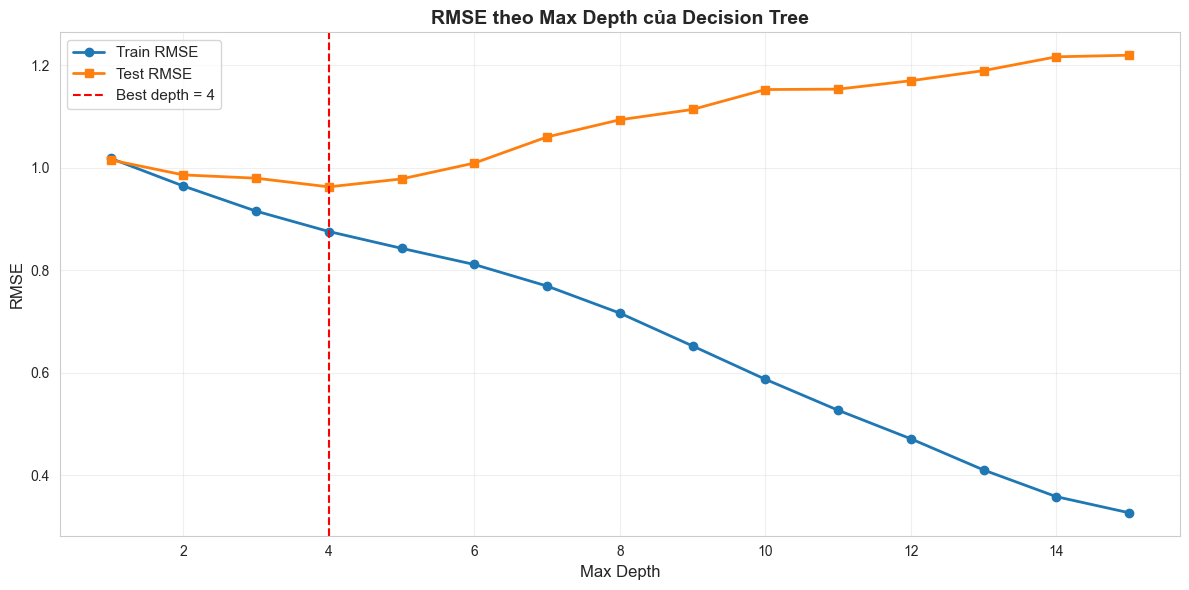

In [49]:
max_depth_values = range(1, 16)
train_rmse_scores = []
test_rmse_scores = []
for depth in max_depth_values:
    dt_model = DecisionTreeRegressorManual(max_depth=depth, min_samples_split=5)
    dt_model.fit(X_train, y_train)
    y_train_pred = dt_model.predict(X_train)
    y_test_pred = dt_model.predict(X_test)
    train_rmse = np.sqrt(mean_squared_error_manual(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error_manual(y_test, y_test_pred))
    train_rmse_scores.append(train_rmse)
    test_rmse_scores.append(test_rmse)
    print(f"max_depth={depth:2d} | Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f}")

# max_depth
best_depth = max_depth_values[np.argmin(test_rmse_scores)]
best_test_rmse = min(test_rmse_scores)

print(f"Max_depth tối ưu: {best_depth}")
print(f"Test RMSE tốt nhất: {best_test_rmse:.4f}")

plt.figure(figsize=(12, 6))
plt.plot(max_depth_values, train_rmse_scores, marker='o', label='Train RMSE', linewidth=2)
plt.plot(max_depth_values, test_rmse_scores, marker='s', label='Test RMSE', linewidth=2)
plt.axvline(x=best_depth, color='r', linestyle='--', label=f'Best depth = {best_depth}')
plt.xlabel('Max Depth', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.title('RMSE theo Max Depth của Decision Tree', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Train set:
   RMSE: 0.8757
   MAE:  0.7102

Test set:
   RMSE: 0.9628
   MAE:  0.7766

So sánh dự đoán với thực tế
 Thực tế  Dự đoán   Sai số
       1 2.620690 1.620690
       3 2.620690 0.379310
       3 3.341523 0.341523
       5 4.478723 0.521277
       4 3.380952 0.619048
       4 4.478723 0.478723
       5 4.478723 0.521277
       2 2.825581 0.825581
       3 4.084507 1.084507
       1 2.825581 1.825581


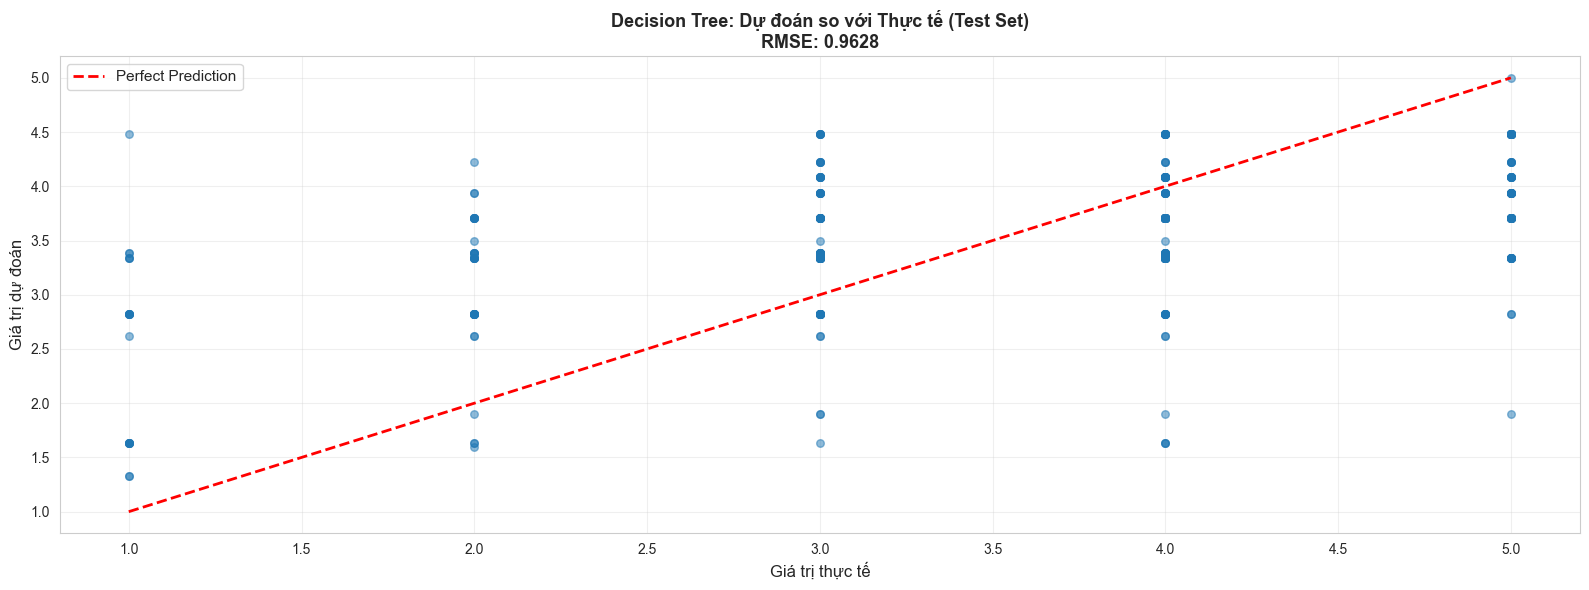

In [46]:
#DECISION TREE (GIẢI TAY)
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value
class DecisionTreeRegressorManual:    
    def __init__(self, max_depth=None, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None
    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        self.root = self._build_tree(X, y, depth=0)
        return self
    def _mse(self, y):
        if len(y) == 0:
            return 0
        mean = np.mean(y)
        return np.mean((y - mean) ** 2)
    def _best_split(self, X, y):
        best_mse = float('inf')
        best_feature = None
        best_threshold = None
        n_samples, n_features = X.shape
        for feature_idx in range(n_features):
            thresholds = np.unique(X[:, feature_idx])
            for i in range(len(thresholds) - 1):
                threshold = (thresholds[i] + thresholds[i + 1]) / 2
                left_mask = X[:, feature_idx] <= threshold
                right_mask = ~left_mask
                if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                    continue
                y_left = y[left_mask]
                y_right = y[right_mask]
                n_left = len(y_left)
                n_right = len(y_right)
                mse = (n_left * self._mse(y_left) + n_right * self._mse(y_right)) / n_samples
                if mse < best_mse:
                    best_mse = mse
                    best_feature = feature_idx
                    best_threshold = threshold
        return best_feature, best_threshold
    def _build_tree(self, X, y, depth):
        n_samples = len(y)
        if (self.max_depth is not None and depth >= self.max_depth) or \
           n_samples < self.min_samples_split or \
           len(np.unique(y)) == 1:
            return Node(value=np.mean(y))
        feature, threshold = self._best_split(X, y)
        if feature is None:
            return Node(value=np.mean(y))
        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask
        left = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right = self._build_tree(X[right_mask], y[right_mask], depth + 1)
        return Node(feature=feature, threshold=threshold, left=left, right=right)
    def _predict_sample(self, x, node):
        if node.value is not None:
            return node.value
        if x[node.feature] <= node.threshold:
            return self._predict_sample(x, node.left)
        else:
            return self._predict_sample(x, node.right)
    def predict(self, X):
        X = np.array(X)
        return np.array([self._predict_sample(x, self.root) for x in X])

final_dt_model = DecisionTreeRegressorManual(max_depth=best_depth, min_samples_split=5)
final_dt_model.fit(X_train, y_train)
y_train_pred = final_dt_model.predict(X_train)
y_test_pred = final_dt_model.predict(X_test)
train_rmse = np.sqrt(mean_squared_error_manual(y_train, y_train_pred))
train_mae = mean_absolute_error_manual(y_train, y_train_pred)
test_rmse = np.sqrt(mean_squared_error_manual(y_test, y_test_pred))
test_mae = mean_absolute_error_manual(y_test, y_test_pred)

print(f"\nTrain set:")
print(f"   RMSE: {train_rmse:.4f}")
print(f"   MAE:  {train_mae:.4f}")
print(f"\nTest set:")
print(f"   RMSE: {test_rmse:.4f}")
print(f"   MAE:  {test_mae:.4f}")

print("\nSo sánh dự đoán với thực tế")
comparison_df = pd.DataFrame({
    'Thực tế': y_test.values[:10],
    'Dự đoán': y_test_pred[:10],
    'Sai số': np.abs(y_test.values[:10] - y_test_pred[:10])
})
print(comparison_df.to_string(index=False))

fig, ax = plt.subplots(1, 1, figsize=(16, 6))
ax.scatter(y_test, y_test_pred, alpha=0.5, s=30)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('Giá trị thực tế', fontsize=12)
ax.set_ylabel('Giá trị dự đoán', fontsize=12)
ax.set_title(f'Decision Tree: Dự đoán so với Thực tế (Test Set)\nRMSE: {test_rmse:.4f}', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Số cây: 100
Learning rate: 0.1
Max depth: 4

Tree   1/100 | Train RMSE: 1.0719
Tree  20/100 | Train RMSE: 0.8208
Tree  40/100 | Train RMSE: 0.7547
Tree  60/100 | Train RMSE: 0.7153
Tree  80/100 | Train RMSE: 0.6837
Tree 100/100 | Train RMSE: 0.6513

Train set:
RMSE: 0.6513
MAE:  0.5186
Test set:
RMSE: 0.9509
MAE:  0.7581

So sánh kết quả dự đoán với thực tế:
 Thực tế  Dự đoán   Sai số
       1 1.998355 0.998355
       3 2.744941 0.255059
       3 3.346152 0.346152
       5 4.806718 0.193282
       4 3.425345 0.574655
       4 4.493888 0.493888
       5 4.647376 0.352624
       2 1.902478 0.097522
       3 3.719999 0.719999
       1 3.088241 2.088241


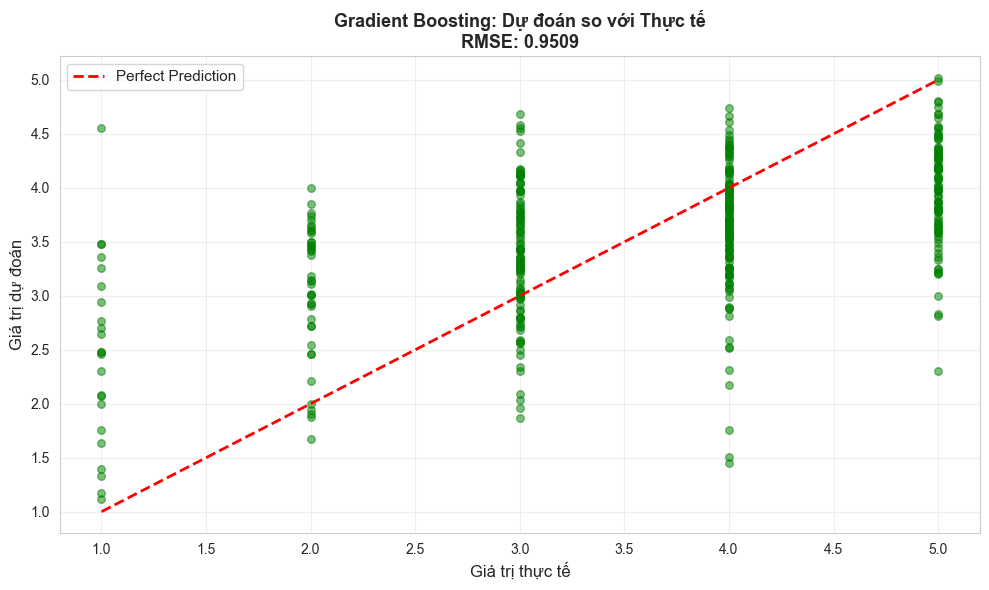

In [47]:
# GRADIENT BOOSTING (GIẢI TAY)
class GradientBoostingRegressorManual:    
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3, min_samples_split=2):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.trees = []
        self.initial_prediction = None
    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        self.initial_prediction = np.mean(y)
        predictions = np.full(len(y), self.initial_prediction)
        for i in range(self.n_estimators):
            residuals = y - predictions
            tree = DecisionTreeRegressorManual(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split
            )
            tree.fit(X, residuals)
            tree_predictions = tree.predict(X)
            predictions += self.learning_rate * tree_predictions
            self.trees.append(tree)
            
            if (i + 1) % 20 == 0 or i == 0:
                mse = np.mean((y - predictions) ** 2)
                rmse = np.sqrt(mse)
                print(f"Tree {i+1:3d}/{self.n_estimators} | Train RMSE: {rmse:.4f}")
        return self
    
    def predict(self, X):
        X = np.array(X)
        predictions = np.full(len(X), self.initial_prediction)
        for tree in self.trees:
            predictions += self.learning_rate * tree.predict(X)
        return predictions

gb_model = GradientBoostingRegressorManual(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    min_samples_split=5
)
print(f"Số cây: {gb_model.n_estimators}")
print(f"Learning rate: {gb_model.learning_rate}")
print(f"Max depth: {gb_model.max_depth}\n")
gb_model.fit(X_train, y_train)

y_train_pred_gb = gb_model.predict(X_train)
y_test_pred_gb = gb_model.predict(X_test)

train_rmse_gb = np.sqrt(mean_squared_error_manual(y_train, y_train_pred_gb))
train_mae_gb = mean_absolute_error_manual(y_train, y_train_pred_gb)
test_rmse_gb = np.sqrt(mean_squared_error_manual(y_test, y_test_pred_gb))
test_mae_gb = mean_absolute_error_manual(y_test, y_test_pred_gb)

print(f"\nTrain set:")
print(f"RMSE: {train_rmse_gb:.4f}")
print(f"MAE:  {train_mae_gb:.4f}")
print(f"Test set:")
print(f"RMSE: {test_rmse_gb:.4f}")
print(f"MAE:  {test_mae_gb:.4f}")

print("\nSo sánh kết quả dự đoán với thực tế:")
comparison_df_gb = pd.DataFrame({
    'Thực tế': y_test.values[:10],
    'Dự đoán': y_test_pred_gb[:10],
    'Sai số': np.abs(y_test.values[:10] - y_test_pred_gb[:10])
})
print(comparison_df_gb.to_string(index=False))

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.scatter(y_test, y_test_pred_gb, alpha=0.5, s=30, c='green')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
        'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('Giá trị thực tế', fontsize=12)
ax.set_ylabel('Giá trị dự đoán', fontsize=12)
ax.set_title(f'Gradient Boosting: Dự đoán so với Thực tế\nRMSE: {test_rmse_gb:.4f}', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

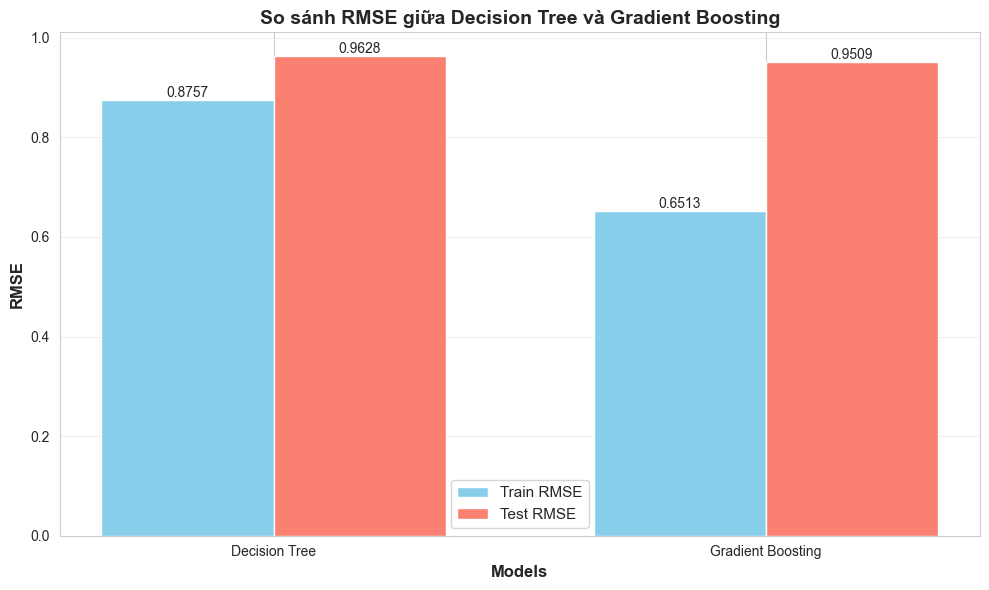

In [48]:
# SO SÁNH RMSE CỦA 2 MÔ HÌNH
models = ['Decision Tree', 'Gradient Boosting']
train_rmse_values = [train_rmse, train_rmse_gb]
test_rmse_values = [test_rmse, test_rmse_gb]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, train_rmse_values, width, label='Train RMSE', color='skyblue')
bars2 = ax.bar(x + width/2, test_rmse_values, width, label='Test RMSE', color='salmon')

ax.set_xlabel('Models', fontsize=12, fontweight='bold')
ax.set_ylabel('RMSE', fontsize=12, fontweight='bold')
ax.set_title('So sánh RMSE giữa Decision Tree và Gradient Boosting', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()